**IRIS data loading, preparation, classification**

Fabio Scotti fabio.scotti@unimi.it

Course: Intelligent systems for industry, supply chain and environment

A Matalb demo for 
 - loading a the IRIS dataset
 - preparing the variables

Import libraries

In [0]:
import pandas as pd #Python Data Analysis Library 
import numpy as np #Python Scientific Library 
from matplotlib import pyplot as plt

Load data

In [49]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
new_names = ['sepal_length','sepal_width','petal_length','petal_width','iris_class']
dataset = pd.read_csv(url, names=new_names, skiprows=0, delimiter=',')
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   iris_class    150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


Take a peek on data

In [50]:
dataset.head(10)

,sepal_length,sepal_width,petal_length,petal_width,iris_class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


We need to separate the feature inputs (x) and the target class (y)

In [51]:
y = dataset['iris_class']
x = dataset.drop(['iris_class'], axis=1)

print ("dataset : ",dataset.shape)
print ("x : ",x.shape)
print ("y : ",y.shape)

dataset :  (150, 5)
x :  (150, 4)
y :  (150,)


Convert dataset format into an array

In [0]:
xNumpy = x.to_numpy()
yNumpy = y.to_numpy()

Read a specific feature

In [53]:
feature_to_extract = 1
feature = xNumpy[:,feature_to_extract]
print(feature)

[3.5 3.  3.2 3.1 3.6 3.9 3.4 3.4 2.9 3.1 3.7 3.4 3.  3.  4.  4.4 3.9 3.5
 3.8 3.8 3.4 3.7 3.6 3.3 3.4 3.  3.4 3.5 3.4 3.2 3.1 3.4 4.1 4.2 3.1 3.2
 3.5 3.1 3.  3.4 3.5 2.3 3.2 3.5 3.8 3.  3.8 3.2 3.7 3.3 3.2 3.2 3.1 2.3
 2.8 2.8 3.3 2.4 2.9 2.7 2.  3.  2.2 2.9 2.9 3.1 3.  2.7 2.2 2.5 3.2 2.8
 2.5 2.8 2.9 3.  2.8 3.  2.9 2.6 2.4 2.4 2.7 2.7 3.  3.4 3.1 2.3 3.  2.5
 2.6 3.  2.6 2.3 2.7 3.  2.9 2.9 2.5 2.8 3.3 2.7 3.  2.9 3.  3.  2.5 2.9
 2.5 3.6 3.2 2.7 3.  2.5 2.8 3.2 3.  3.8 2.6 2.2 3.2 2.8 2.8 2.7 3.3 3.2
 2.8 3.  2.8 3.  2.8 3.8 2.8 2.8 2.6 3.  3.4 3.1 3.  3.1 3.1 3.1 2.7 3.2
 3.3 3.  2.5 3.  3.4 3. ]


Read a specific sample

In [54]:
sample_to_extract = 1
sample = xNumpy[sample_to_extract,:]
print(sample)

[4.9 3.  1.4 0.2]


Normalize data

In [0]:
xNumpy_Norm = (xNumpy - np.min(xNumpy)) / (np.max(xNumpy) - np.min(xNumpy))

Plot non-normalized and normalized data

(array([ 9., 23., 14., 27., 16., 26., 18.,  6.,  5.,  6.]),
 array([0.53846154, 0.58461538, 0.63076923, 0.67692308, 0.72307692,
        0.76923077, 0.81538462, 0.86153846, 0.90769231, 0.95384615,
        1.        ]),
 <a list of 10 Patch objects>)

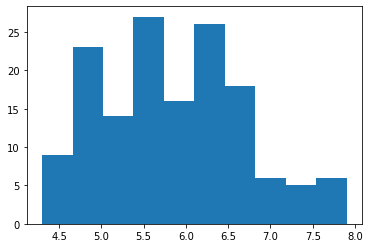

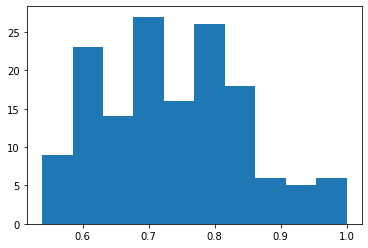

In [56]:
plt.subplots()
plt.hist(xNumpy[:,0])
plt.subplots()
plt.hist(xNumpy_Norm[:,0])

Convert class from categorical to numeric

In [57]:
yNumpy, dummy = pd.factorize(yNumpy)
print(yNumpy)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


Plot features and classes

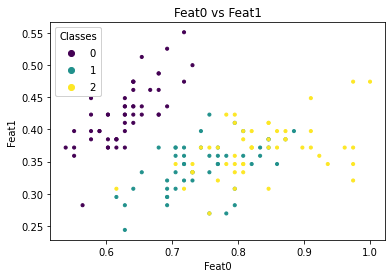

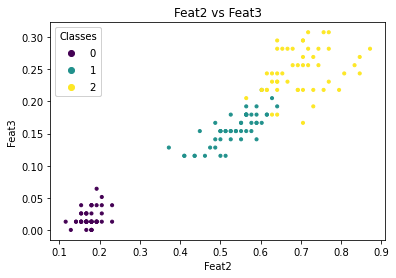

In [58]:
import matplotlib.pyplot as plt
# select 2 features to plot
feat0 = xNumpy_Norm[:,0]
feat1 = xNumpy_Norm[:,1]
# params
area = np.pi*3
# Plot
fig1, ax1 = plt.subplots()
scatter1 = ax1.scatter(feat0, feat1, s=area, c=yNumpy)
plt.title('Feat0 vs Feat1')
plt.xlabel('Feat0')
plt.ylabel('Feat1')
legend1 = ax1.legend(*scatter1.legend_elements(),
                    loc="upper left", title="Classes")
ax1.add_artist(legend1)
plt.show()

# select 2 features to plot
feat2 = xNumpy_Norm[:,2]
feat3 = xNumpy_Norm[:,3]
# params
area = np.pi*3
# Plot
fig2, ax2 = plt.subplots()
scatter2 = ax2.scatter(feat2, feat3, s=area, c=yNumpy)
plt.title('Feat2 vs Feat3')
plt.xlabel('Feat2')
plt.ylabel('Feat3')
legend2 = ax2.legend(*scatter2.legend_elements(),
                    loc="upper left", title="Classes")
ax2.add_artist(legend2)
plt.show()

Split data in train and test

In [59]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(xNumpy, yNumpy, test_size=0.5)
print("Dimensione xTrain: {0}".format(x_train.shape))
print("Dimensione xTest: {0}".format(x_test.shape))
print("Dimensione yTrain: {0}".format(y_train.shape))
print("Dimensione yTest: {0}".format(y_test.shape))

Dimensione xTrain: (75, 4)
Dimensione xTest: (75, 4)
Dimensione yTrain: (75,)
Dimensione yTest: (75,)


Create kNN classifier

In [0]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors=1, metric='euclidean')


Train classifier on training data

In [61]:
classifier.fit(x_train, y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='euclidean',
                     metric_params=None, n_jobs=None, n_neighbors=1, p=2,
                     weights='uniform')

Test classifier on test data

In [0]:
output_test = classifier.predict(x_test)

Compute confusion matrix

In [63]:
from sklearn.metrics import confusion_matrix
CM = confusion_matrix(y_test, output_test)
print(CM)

[[27  0  0]
 [ 0 21  2]
 [ 0  0 25]]


Compute accuracy

In [64]:
diagonal_sum = CM.trace()
sum_of_all_elements = CM.sum()
accuracy = diagonal_sum / sum_of_all_elements
print("Accuracy: {0}".format(accuracy*100))

Accuracy: 97.33333333333334
